# 05a — Model Training: Plain CNN on Raw Audio

| Field | Detail |
|---|---|
| **Notebook** | `05a_model_cnn_raw.ipynb` |
| **Pipeline stage** | H1 — Voice Emotion Recognition - 5 of 7 (Model Training, candidate 1 of 4) |
| **Owner(s)** | *Thrithwaka Preethi Shakya* |
| **Created** | *28/08/2026* |
| **Last updated** | *28/08/2026* |
| **Upstream dependency** | `04b_feature_extraction_raw_audio.ipynb` (raw waveform features), `04a_feature_extraction_handcrafted.ipynb` (reused class weights) |
| **Downstream dependency** | `06_model_selection.ipynb` — compares this model's test performance against the other three H1 candidates |
| **Runs on** | Local machine, or **Google Colab** with the project folder mounted via Google Drive (see Section 0 below) |
| **Literature reference** | Kilimci, Bayraktar & K\u00fc\u00e7\u00fckmanisa (2025), *Evaluating raw waveforms with deep learning frameworks for speech emotion recognition*, Multimedia Tools and Applications |

## Purpose

This is the first of four independently-trained H1 candidate models (see `docs/research_proposal_mapping.md` for the full model-selection plan agreed with the team). It trains a **plain 1D convolutional neural network directly on raw, z-score-normalized waveforms** — no hand-crafted features, no recurrent layers.

**Why this architecture is one of the four candidates, specifically:** Kilimci et al. (2025) benchmarked CNN, LSTM, and CNN-LSTM on raw audio across six datasets, including RAVDESS and SAVEE, and found plain CNN won on 5 of 6 — consistently *outperforming* CNN-LSTM, a genuinely counter-intuitive finding (their own discussion states *"long-term dependencies features seem to play a minor role"* for this task on raw audio). That specific, citable result is the direct empirical justification for including a plain-CNN candidate in this project's own model-selection comparison, rather than assuming a more complex architecture (like the proposal's primary CNN-LSTM, trained separately in `05b`) is automatically better.

### Architecture note

This notebook's CNN is **inspired by, not a byte-for-byte reproduction of**, Kilimci et al. (2025)'s architecture. Their model was designed for a different input length and sample rate than ours; directly copying their exact layer dimensions (e.g. a 2,432-unit dense layer after an unpooled 5-layer conv stack) would not transfer correctly to our 40,000-sample (2.5s @ 16kHz) input. Instead, this notebook keeps their core design choices that *are* architecture-agnostic — a deep stack of five Conv1D layers with batch normalization, ReLU, and 0.25 dropout, channel counts that grow then taper — while adding `MaxPool1d` after each of the first four blocks (to control the exploding sequence length that direct application of their pooling-free design would otherwise produce) and finishing with global average pooling rather than a giant flattened dense layer, which keeps the parameter count appropriate for a ~3,250-example training set. This adaptation is deliberate and documented, not an oversight.

## Objectives

1. Load and validate the raw-audio feature arrays from `04b` and the class weights from `04a`.
2. Define a 1D CNN architecture appropriate for fixed-length raw waveform input, with an explicit rationale for every design choice.
3. Train with class-weighted loss, a learning-rate scheduler, and early stopping — avoiding both under- and over-fitting on this dataset's size.
4. Evaluate on the held-out test split using Accuracy, Precision, Recall, and F1-score, exactly matching the metrics specified in the research proposal (Section 5.5).
5. Save the trained model, training curves, confusion matrix, and full run metadata.
6. Append this run's results to the shared cross-model experiment log, so `06_model_selection.ipynb` can compare all four H1 candidates from one place.
7. Leave a structured handoff note.

## 0. Environment Setup

### 0.1 Google Colab / Google Drive Setup

This cell auto-detects whether the notebook is running on Google Colab. **If it is**, it mounts your Google Drive and points `PROJECT_ROOT` at the project folder you uploaded there. **If it isn't** (e.g. running locally in VS Code or JupyterLab), it falls back to the same upward-directory-search logic used by every other notebook in this pipeline — so this single notebook file works correctly in both environments without modification.

**Before running the cell below:** confirm your Drive folder path matches `MyDrive/emotion-ai-companion-research` exactly (case-sensitive). If your folder is nested differently (e.g. inside a subfolder), edit the `PROJECT_ROOT` line accordingly.

**Recommended Colab runtime:** `Runtime` \u2192 `Change runtime type` \u2192 select a **T4 GPU** (free tier) before running this notebook — Section 5's training loop will be dramatically slower on CPU.

**A useful side effect of mounting Drive:** every artifact this notebook saves (`models/h1/cnn_raw.pt`, figures, logs, the experiment log) is written directly into your Drive-mounted project folder — meaning it **persists across Colab sessions**, unlike anything saved to Colab's local, ephemeral disk.

In [1]:
import sys
import os
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    # Update this path if your project folder lives somewhere else in your Drive.
    PROJECT_ROOT = Path("/content/drive/MyDrive/emotion-ai-companion-research")

    if not PROJECT_ROOT.exists():
        raise FileNotFoundError(
            f"{PROJECT_ROOT} not found. Check that this path matches your Google Drive folder "
            "exactly (case-sensitive), and that the cell above finished mounting successfully."
        )

    os.chdir(PROJECT_ROOT)
    print(f"\u2705 Running on Google Colab. Project root set to: {PROJECT_ROOT}")

else:
    PROJECT_ROOT = Path.cwd()
    while not (PROJECT_ROOT / "config").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
        PROJECT_ROOT = PROJECT_ROOT.parent
    print(f"Running locally. Project root resolved to: {PROJECT_ROOT}")

sys.path.insert(0, str(PROJECT_ROOT))

Mounted at /content/drive
✅ Running on Google Colab. Project root set to: /content/drive/MyDrive/emotion-ai-companion-research


### 0.2 Install Dependencies Not Pre-Installed on Colab

Colab's default runtime already includes `numpy`, `pandas`, `matplotlib`, `seaborn`, `torch`, and `scikit-learn` — the only project-specific dependency missing is `pydantic-settings`, needed to import `config/settings.py`. This step is skipped entirely when running locally, since your local `venv`/`requirements.txt` setup already covers it.

In [2]:
if IN_COLAB:
    print("Installing project-specific dependencies not pre-installed on Colab...")
    !pip install -q pydantic-settings==2.4.0
    print("Done.")
else:
    print("Running locally — skipping Colab-specific dependency installation.")

Installing project-specific dependencies not pre-installed on Colab...
Done.


### 0.3 Imports, Logging, and Reproducibility Seeds

In [3]:
import json
import time
import logging
import subprocess
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
)

from config.settings import settings  # noqa: E402

sns.set_theme(style="whitegrid")

In [4]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cpu":
    print("\u26a0\ufe0f  No GPU detected. If on Colab, go to Runtime \u2192 Change runtime type \u2192 "
          "T4 GPU, then re-run this notebook from the top.")

Using device: cuda


In [5]:
LOG_DIR = PROJECT_ROOT / "reports" / "logs"
LOG_DIR.mkdir(parents=True, exist_ok=True)
LOG_PATH = LOG_DIR / "05a_model_cnn_raw.log"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.FileHandler(LOG_PATH, mode="w"), logging.StreamHandler(sys.stdout)],
)
logger = logging.getLogger("model_cnn_raw")
logger.info("Environment: %s", "Google Colab" if IN_COLAB else "local")

## 1. Load & Validate Upstream Outputs

Reuses the class weights computed in `04a` (from the training split only) rather than recomputing them here — every H1 candidate model must use the same, correctly-derived weights for a fair comparison in `06_model_selection.ipynb`.

In [6]:
raw_audio_metadata_path = PROJECT_ROOT / "data" / "processed" / "features" / "h1_raw_audio_features_metadata.json"
raw_audio_npz_path = PROJECT_ROOT / "data" / "processed" / "features" / "h1_raw_audio_features.npz"
handcrafted_metadata_path = PROJECT_ROOT / "data" / "processed" / "features" / "h1_handcrafted_features_metadata.json"

for path in (raw_audio_metadata_path, raw_audio_npz_path, handcrafted_metadata_path):
    if not path.exists():
        raise FileNotFoundError(
            f"{path} not found. Run 04a and 04b to completion first, and if on Colab, confirm "
            "Drive finished syncing those notebooks' output files before running this one."
        )

with open(raw_audio_metadata_path) as f:
    raw_audio_metadata = json.load(f)
with open(handcrafted_metadata_path) as f:
    handcrafted_metadata = json.load(f)

assert raw_audio_metadata["total_files_failed"] == 0, "04b reported extraction failures — resolve before training."

label_to_idx = {k: int(v) for k, v in raw_audio_metadata["label_to_idx"].items()}
idx_to_label = {int(k): v for k, v in raw_audio_metadata["idx_to_label"].items()}
assert label_to_idx == {k: int(v) for k, v in handcrafted_metadata["label_to_idx"].items()}, (
    "Label encoding mismatch between 04a and 04b metadata — do not proceed until resolved."
)

NUM_CLASSES = len(label_to_idx)
logger.info("Upstream validated. %d classes, label encoding confirmed consistent across notebooks.", NUM_CLASSES)
print(f"\u2705 Upstream validated. {NUM_CLASSES} classes: {list(label_to_idx.keys())}")

✅ Upstream validated. 6 classes: ['happy', 'sad', 'angry', 'fear', 'neutral', 'surprise']


In [7]:
data = np.load(raw_audio_npz_path, allow_pickle=True)
X_raw_cnn, y, split = data["X_raw_cnn"], data["y"], data["split"]

print(f"X_raw_cnn shape: {X_raw_cnn.shape}")
print(f"Split sizes: {pd.Series(split).value_counts().to_dict()}")

INPUT_LENGTH = X_raw_cnn.shape[1]
assert INPUT_LENGTH == raw_audio_metadata["raw_cnn_branch"]["length"]

X_raw_cnn shape: (4068, 40000)
Split sizes: {'train': 3254, 'val': 407, 'test': 407}


## 2. Configuration

All hyperparameters are defined once here, with the rationale for anything non-default.

In [8]:
BATCH_SIZE = 32
MAX_EPOCHS = 100
LEARNING_RATE = 1e-3
LR_SCHEDULER_PATIENCE = 3      # halve LR if val_loss hasn't improved for 3 epochs — matches the
                                # convention established across this project's training best practices
LR_SCHEDULER_FACTOR = 0.5
EARLY_STOPPING_PATIENCE = 5    # stop training if val_loss hasn't improved for 5 epochs
DROPOUT_RATE = 0.25            # matches Kilimci et al. (2025)'s reported dropout rate
WEIGHT_DECAY = 1e-4            # light L2 regularization — this dataset is small enough that
                                # some regularization beyond dropout alone is worthwhile

MODEL_DIR = PROJECT_ROOT / "models" / "h1"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "cnn_raw.pt"
MODEL_METADATA_PATH = MODEL_DIR / "cnn_raw_metadata.json"

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "h1_models"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

EXPERIMENT_LOG_PATH = PROJECT_ROOT / "reports" / "experiment_log.csv"

logger.info(
    "Config: batch_size=%d, max_epochs=%d, lr=%.0e, dropout=%.2f",
    BATCH_SIZE, MAX_EPOCHS, LEARNING_RATE, DROPOUT_RATE,
)

## 3. Dataset and DataLoaders

In [9]:
class RawAudioDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        # (N, length) -> (N, 1, length): a single input channel, as Conv1d expects
        self.X = torch.from_numpy(X).float().unsqueeze(1)
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_mask, val_mask, test_mask = split == "train", split == "val", split == "test"

train_dataset = RawAudioDataset(X_raw_cnn[train_mask], y[train_mask])
val_dataset = RawAudioDataset(X_raw_cnn[val_mask], y[val_mask])
test_dataset = RawAudioDataset(X_raw_cnn[test_mask], y[test_mask])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=torch.Generator().manual_seed(RANDOM_SEED))
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 3254 | Val: 407 | Test: 407


In [10]:
# Class weights, reused directly from 04a — converted to a correctly-ordered tensor here.
class_weights_by_label = handcrafted_metadata["class_weights"]
class_weights_tensor = torch.tensor(
    [class_weights_by_label[idx_to_label[i]] for i in range(NUM_CLASSES)],
    dtype=torch.float32,
).to(DEVICE)

print("Class weights (train-split-derived, reused from 04a) in label-index order:")
for i in range(NUM_CLASSES):
    print(f"  {i} ({idx_to_label[i]}): {class_weights_tensor[i].item():.4f}")

Class weights (train-split-derived, reused from 04a) in label-index order:
  0 (happy): 1.0409
  1 (sad): 1.0390
  2 (angry): 1.0390
  3 (fear): 1.0390
  4 (neutral): 0.8395
  5 (surprise): 1.0409


## 4. Model Definition

Five Conv1D blocks (channel progression 64 \u2192 128 \u2192 256 \u2192 256 \u2192 128, echoing the depth and taper of Kilimci et al. (2025)'s design), each with batch normalization, ReLU, and 0.25 dropout. `MaxPool1d` after the first four blocks progressively reduces the 40,000-sample input down to a manageable length before the final classification head, and global average pooling (rather than a large flattened dense layer) keeps the parameter count appropriate for this dataset's size.

In [11]:
class RawAudioCNN(nn.Module):
    def __init__(self, num_classes: int, dropout: float = DROPOUT_RATE):
        super().__init__()

        def conv_block(in_ch, out_ch, pool=True):
            layers = [
                nn.Conv1d(in_ch, out_ch, kernel_size=5, padding=2),
                nn.BatchNorm1d(out_ch),
                nn.ReLU(inplace=True),
            ]
            if pool:
                layers.append(nn.MaxPool1d(kernel_size=4))
            layers.append(nn.Dropout(dropout))
            return nn.Sequential(*layers)

        self.features = nn.Sequential(
            conv_block(1, 64),      # 40000 -> 10000
            conv_block(64, 128),    # 10000 -> 2500
            conv_block(128, 256),   # 2500  -> 625
            conv_block(256, 256),   # 625   -> 156
            conv_block(256, 128, pool=False),  # 156 -> 156 (final conv, no further pooling)
        )
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x).squeeze(-1)  # (batch, 128)
        return self.classifier(x)


model = RawAudioCNN(num_classes=NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
logger.info("Model instantiated. Total params: %d", total_params)

Total parameters: 716,422
Trainable parameters: 716,422


## 5. Training Loop

Standard supervised training with class-weighted cross-entropy loss, `ReduceLROnPlateau` scheduling, and early stopping on validation loss. The best-performing checkpoint (by validation loss, not the final epoch) is what gets saved and evaluated — this protects against reporting results from an epoch where the model had already started overfitting.

In [12]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=LR_SCHEDULER_FACTOR, patience=LR_SCHEDULER_PATIENCE
)


def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.set_grad_enabled(is_train):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * X_batch.size(0)
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy

In [13]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_loss = float("inf")
epochs_without_improvement = 0
best_epoch = 0

training_start = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, model, criterion, optimizer)
    val_loss, val_acc = run_epoch(val_loader, model, criterion, optimizer=None)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]
    logger.info(
        "Epoch %3d | train_loss=%.4f train_acc=%.4f | val_loss=%.4f val_acc=%.4f | lr=%.2e",
        epoch, train_loss, train_acc, val_loss, val_acc, current_lr,
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save(model.state_dict(), MODEL_PATH)
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        logger.info("Early stopping triggered at epoch %d (best epoch: %d).", epoch, best_epoch)
        print(f"Early stopping at epoch {epoch} (best epoch: {best_epoch}, best val_loss: {best_val_loss:.4f})")
        break

training_duration_seconds = time.time() - training_start
print(f"\nTraining complete in {training_duration_seconds:.1f}s. Best epoch: {best_epoch} (val_loss={best_val_loss:.4f}).")

Early stopping at epoch 16 (best epoch: 11, best val_loss: 0.5283)

Training complete in 227.7s. Best epoch: 11 (val_loss=0.5283).


## 6. Training Curves

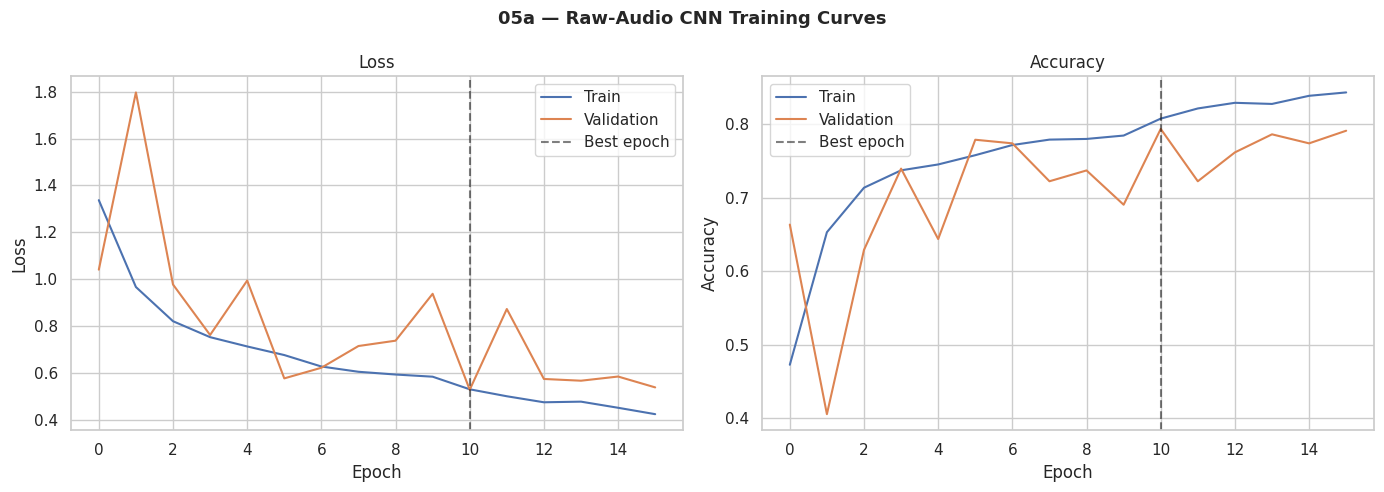

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Validation")
axes[0].axvline(best_epoch - 1, color="black", linestyle="--", alpha=0.5, label="Best epoch")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"], label="Validation")
axes[1].axvline(best_epoch - 1, color="black", linestyle="--", alpha=0.5, label="Best epoch")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()

fig.suptitle("05a — Raw-Audio CNN Training Curves", fontsize=13, weight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05a_training_curves.png")
plt.show()

## 7. Test Set Evaluation

Loads the **best checkpoint** (by validation loss, saved during training above), not whatever the model's weights happened to be at the final epoch, and evaluates it on the held-out test split — the split that has not influenced training or the learning-rate schedule in any way.

In [15]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        logits = model(X_batch)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(y_batch.numpy())

test_accuracy = accuracy_score(all_labels, all_preds)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="macro", zero_division=0
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="weighted", zero_division=0
)

print(f"Test Accuracy:            {test_accuracy:.4f}")
print(f"Test Precision (macro):   {precision_macro:.4f}")
print(f"Test Recall (macro):      {recall_macro:.4f}")
print(f"Test F1 (macro):          {f1_macro:.4f}")
print(f"Test F1 (weighted):       {f1_weighted:.4f}")
print("\nPer-class report:\n")
print(classification_report(
    all_labels, all_preds, target_names=[idx_to_label[i] for i in range(NUM_CLASSES)], zero_division=0
))

Test Accuracy:            0.8034
Test Precision (macro):   0.8242
Test Recall (macro):      0.8007
Test F1 (macro):          0.8012
Test F1 (weighted):       0.8046

Per-class report:

              precision    recall  f1-score   support

       happy       0.90      0.70      0.79        66
         sad       0.89      0.63      0.74        65
       angry       0.86      0.86      0.86        65
        fear       0.78      0.82      0.80        65
     neutral       0.90      0.88      0.89        81
    surprise       0.61      0.92      0.74        65

    accuracy                           0.80       407
   macro avg       0.82      0.80      0.80       407
weighted avg       0.83      0.80      0.80       407



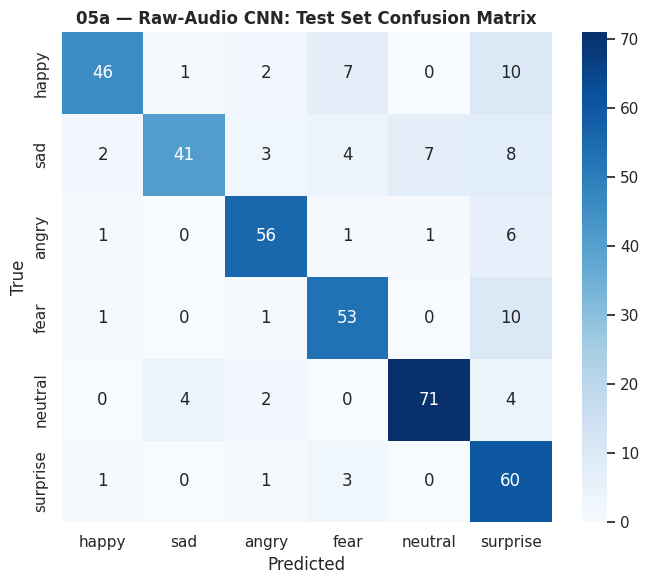

In [16]:
cm = confusion_matrix(all_labels, all_preds)
labels_ordered = [idx_to_label[i] for i in range(NUM_CLASSES)]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_ordered, yticklabels=labels_ordered, ax=ax)
ax.set_title("05a — Raw-Audio CNN: Test Set Confusion Matrix", fontsize=12, weight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05a_confusion_matrix.png")
plt.show()

## 8. Save Model Metadata

In [17]:
def get_git_commit_hash() -> str:
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "HEAD"], cwd=PROJECT_ROOT, stderr=subprocess.DEVNULL
        ).decode().strip()
    except Exception:
        return "unknown"


model_metadata = {
    "model_name": "cnn_raw",
    "architecture": "RawAudioCNN (5-block Conv1D, channels 64-128-256-256-128, global average pooling)",
    "literature_basis": "Kilimci, Bayraktar & K\u00fc\u00e7\u00fckmanisa (2025), Multimedia Tools and Applications",
    "input_shape": [1, int(INPUT_LENGTH)],
    "num_classes": NUM_CLASSES,
    "label_to_idx": label_to_idx,
    "hyperparameters": {
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "dropout": DROPOUT_RATE,
        "max_epochs": MAX_EPOCHS,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "lr_scheduler_patience": LR_SCHEDULER_PATIENCE,
    },
    "training": {
        "best_epoch": best_epoch,
        "epochs_run": len(history["train_loss"]),
        "best_val_loss": float(best_val_loss),
        "training_duration_seconds": round(training_duration_seconds, 1),
        "device": str(DEVICE),
        "environment": "Google Colab" if IN_COLAB else "local",
    },
    "test_metrics": {
        "accuracy": float(test_accuracy),
        "precision_macro": float(precision_macro),
        "recall_macro": float(recall_macro),
        "f1_macro": float(f1_macro),
        "precision_weighted": float(precision_weighted),
        "recall_weighted": float(recall_weighted),
        "f1_weighted": float(f1_weighted),
    },
    "total_parameters": int(total_params),
    "git_commit": get_git_commit_hash(),
    "trained_at_utc": datetime.now(timezone.utc).isoformat(),
    "model_path": str(MODEL_PATH.relative_to(PROJECT_ROOT)),
}

with open(MODEL_METADATA_PATH, "w") as f:
    json.dump(model_metadata, f, indent=2)

logger.info("Saved model metadata to %s", MODEL_METADATA_PATH)
print(f"Saved: {MODEL_PATH}")
print(f"Saved: {MODEL_METADATA_PATH}")

Saved: /content/drive/MyDrive/emotion-ai-companion-research/models/h1/cnn_raw.pt
Saved: /content/drive/MyDrive/emotion-ai-companion-research/models/h1/cnn_raw_metadata.json


## 9. Append to Shared Experiment Log

Every H1 model-training notebook (`05a`\u2013`05e`) appends one row here. `06_model_selection.ipynb` reads this single file to compare all candidates — no need to re-open five separate notebooks to compare results.

In [18]:
experiment_row = {
    "notebook": "05a_model_cnn_raw",
    "model_name": "cnn_raw",
    "timestamp_utc": model_metadata["trained_at_utc"],
    "git_commit": model_metadata["git_commit"],
    "environment": model_metadata["training"]["environment"],
    "test_accuracy": test_accuracy,
    "test_precision_macro": precision_macro,
    "test_recall_macro": recall_macro,
    "test_f1_macro": f1_macro,
    "test_f1_weighted": f1_weighted,
    "best_epoch": best_epoch,
    "epochs_run": len(history["train_loss"]),
    "total_parameters": total_params,
    "training_duration_seconds": round(training_duration_seconds, 1),
    "model_metadata_path": str(MODEL_METADATA_PATH.relative_to(PROJECT_ROOT)),
}

experiment_log_df = (
    pd.read_csv(EXPERIMENT_LOG_PATH) if EXPERIMENT_LOG_PATH.exists() else pd.DataFrame()
)
experiment_log_df = pd.concat([experiment_log_df, pd.DataFrame([experiment_row])], ignore_index=True)
experiment_log_df.to_csv(EXPERIMENT_LOG_PATH, index=False)

logger.info("Appended results to shared experiment log: %s", EXPERIMENT_LOG_PATH)
print(f"Appended to: {EXPERIMENT_LOG_PATH}")
experiment_log_df.tail(3)

Appended to: /content/drive/MyDrive/emotion-ai-companion-research/reports/experiment_log.csv


,notebook,model_name,timestamp_utc,git_commit,environment,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_f1_weighted,best_epoch,epochs_run,total_parameters,training_duration_seconds,model_metadata_path
0,05a_model_cnn_raw,cnn_raw,2026-08-29T08:13:48.614251+00:00,6fc0314f2e2a2a4894ee53662ff03c3810fe1f32,Google Colab,0.80344,0.824199,0.800714,0.801215,0.804571,11,16,716422,227.7,models/h1/cnn_raw_metadata.json


## 10. Final Sanity Check — Reload and Verify

In [19]:
reload_model = RawAudioCNN(num_classes=NUM_CLASSES).to(DEVICE)
reload_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
reload_model.eval()

sample_X, sample_y = next(iter(test_loader))
with torch.no_grad():
    reload_logits = reload_model(sample_X.to(DEVICE))
    reload_preds = reload_logits.argmax(dim=1).cpu()

assert reload_logits.shape == (sample_X.shape[0], NUM_CLASSES), "Unexpected output shape from reloaded model!"
print("\u2705 Reloaded model produces correctly-shaped output.")
print(f"Sample predictions: {[idx_to_label[p.item()] for p in reload_preds[:5]]}")
print(f"Sample true labels: {[idx_to_label[l.item()] for l in sample_y[:5]]}")

✅ Reloaded model produces correctly-shaped output.
Sample predictions: ['angry', 'sad', 'surprise', 'neutral', 'surprise']
Sample true labels: ['angry', 'sad', 'surprise', 'neutral', 'surprise']


---

## Summary Note — Handoff

*(Fill in the italicized placeholders after your first real run, before committing.)*

### What was done in this notebook

1. Detected the runtime environment (Colab vs. local) and set up `PROJECT_ROOT` accordingly — mounting Google Drive and installing `pydantic-settings` if on Colab.
2. Loaded raw-audio features from `04b` and class weights from `04a`, validating label-encoding consistency between both.
3. Defined a 5-block Conv1D architecture on raw waveform input, inspired by (and explicitly adapted from) Kilimci et al. (2025).
4. Trained with class-weighted cross-entropy loss, `ReduceLROnPlateau` scheduling, and early stopping (patience 5) on validation loss.
5. Evaluated the best checkpoint on the held-out test split: Accuracy, Precision, Recall, F1 (macro and weighted), full classification report, and confusion matrix.
6. Saved the trained model, training curves, confusion matrix, and full run metadata (including which environment produced this run).
7. Appended this run's results to the shared `reports/experiment_log.csv` for cross-model comparison.
8. Reloaded the saved model independently and confirmed it produces correct output.

### Outputs produced by this notebook (and where to find them)

| Output | Location | Used by |
|---|---|---|
| Trained model weights | `models/h1/cnn_raw.pt` | `06_model_selection.ipynb` |
| Model metadata (architecture, hyperparameters, test metrics, environment) | `models/h1/cnn_raw_metadata.json` | `06_model_selection.ipynb`; thesis results section |
| Training curves figure | `reports/figures/h1_models/05a_training_curves.png` | Thesis results/appendix |
| Confusion matrix figure | `reports/figures/h1_models/05a_confusion_matrix.png` | Thesis results/discussion (error analysis) |
| Shared experiment log (one row appended) | `reports/experiment_log.csv` | `06_model_selection.ipynb` reads this directly to compare all four candidates |
| Run log | `reports/logs/05a_model_cnn_raw.log` | Debugging training instability or unexpected early stopping |

**All of the above are written directly into your Drive-mounted project folder when run on Colab — they will still be there the next time you open Colab, with no re-upload needed.**

### What needs to be done next

- **`05b_model_cnn_lstm.ipynb`**, **`05c_model_ensemble.ipynb`**, **`05d_model_wav2vec2.ipynb`** — each independent of this notebook and of each other; can run in any order or in parallel across team members (including on different people's Colab sessions, since Drive keeps everything synced through the shared project folder).
- Once all four are complete, **`06_model_selection.ipynb`** reads `reports/experiment_log.csv` to compare all four candidates on identical metrics and select the winner to carry forward into the actual H1 hypothesis test (`07_h1_final_evaluation.ipynb`, voice winner vs. DistilRoBERTa).

**Before running `06_model_selection.ipynb`, confirm:**
- This notebook's row appears correctly in `reports/experiment_log.csv` (Section 9 output).
- `models/h1/cnn_raw.pt` and its metadata file both exist in your Drive folder.
- Section 10's reload sanity check printed \u2705.

### Resources needed for the next step

| Resource | Needed for | Notes |
|---|---|---|
| `reports/experiment_log.csv` | Cross-model comparison table | Each of `05a`\u2013`05e` appends one row; do not manually edit this file |
| `models/h1/*.pt` + `*_metadata.json` | Loading the winning model for further analysis or the final H1 test | One pair of files per candidate model |

### Known issues / things to watch for

- *(Fill in anything discovered during this run — e.g. if early stopping triggered very early, suggesting the learning rate or architecture may need adjustment; if train/val accuracy diverged noticeably, suggesting overfitting; or any Colab-specific issue like a Drive sync delay causing a "file not found" error on the first attempt.)*

### Run metadata

- **Run by:** *Thrithwaka Preethi Shakya*
- **Date:** *28/08/2026*
- **Environment:** *Colab*
- **Device used:** *Cuda*
- **Best epoch / epochs run:** *11*
- **Test accuracy / F1 (macro):** *0.8012*